Total Revenue 1783045294.762204
Total Orders 2406

Sales by Status Order Status
Cancelled         4.937488e+08
Delivered         1.227420e+09
FailedDelivery    5.904600e+04
InvalidOrder      6.181470e+07
Packed            2.760000e+03
Name: Total Price, dtype: float64


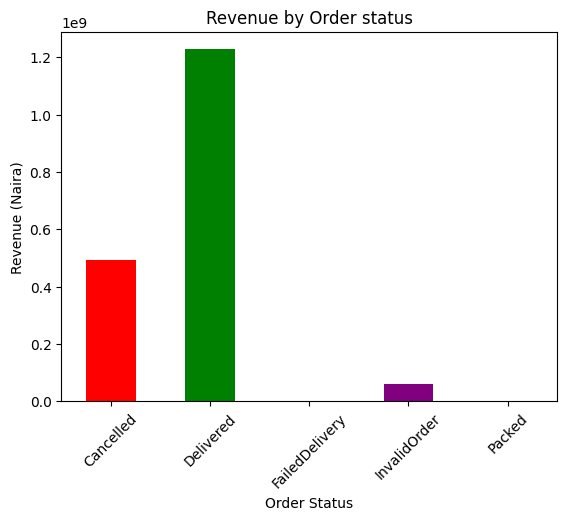

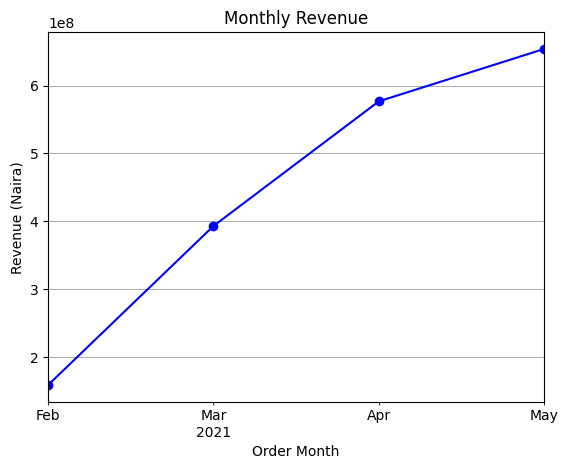

Item Name
Milo Sachet 20g                      284732521.0
Knorr Chicken 17x50x8g               168711874.0
Maize                                115673000.0
Milo 20g                             104828250.0
Close Up Ever Fresh Red Hot 140g      73667378.0
MILO - 240x20g                        63700000.0
Soybean                               62580000.0
Milo Refill Pack - 450g               61843350.0
NESTLE GOLDEN MORN 50G                59559096.0
3CROWNS EVAPORATED -TIN 24 X 160g     46576220.0
Name: Total Price, dtype: float64


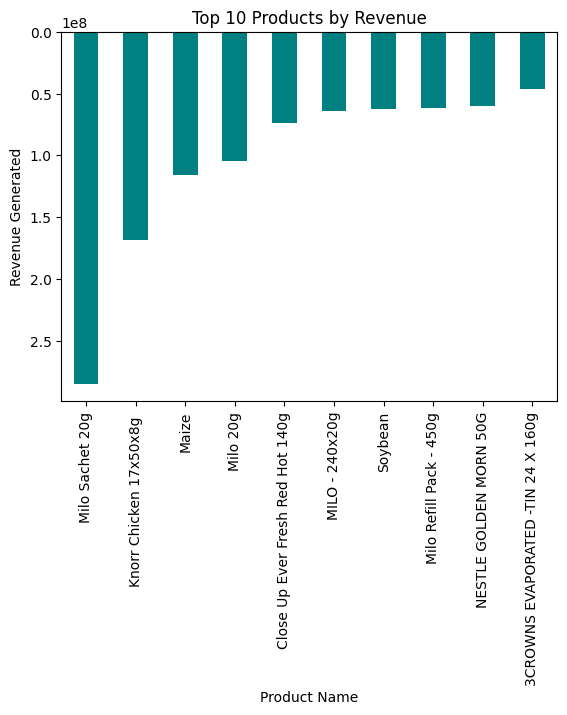

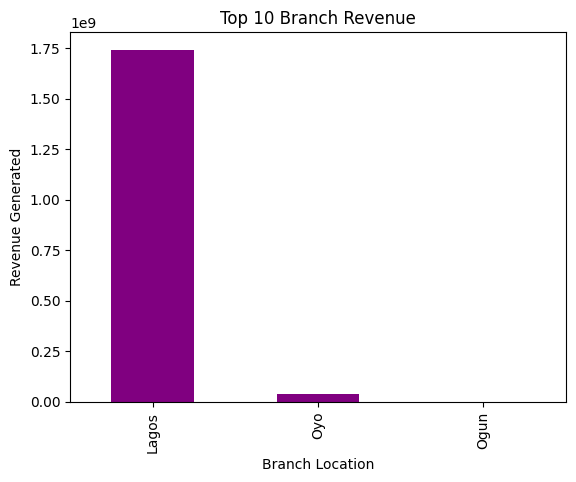

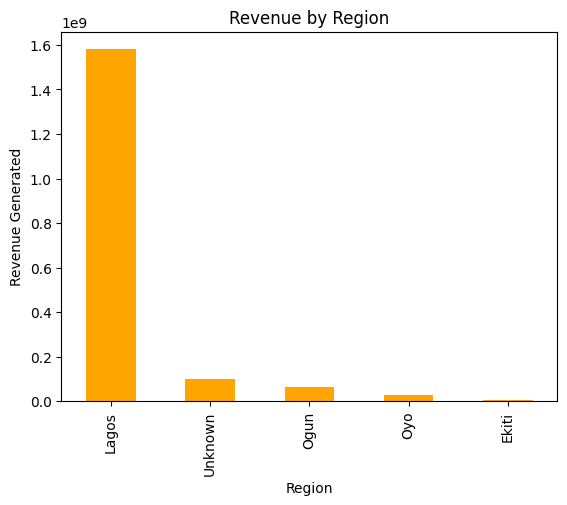

Order Status
Cancelled         27.691319
Delivered         68.838410
FailedDelivery     0.003312
InvalidOrder       3.466805
Packed             0.000155
Name: Total Price, dtype: float64
Order Status
Cancelled         1484
Delivered         1055
FailedDelivery       4
InvalidOrder        99
Packed               1
Name: Order ID, dtype: int64
Order Status
Cancelled         3.327148e+05
Delivered         1.163431e+06
FailedDelivery    1.476150e+04
InvalidOrder      6.243909e+05
Packed            2.760000e+03
dtype: float64
Order Region  Item Name                  
Lagos         Milo Sachet 20g                213505643.0
              Knorr Chicken 17x50x8g         150622574.0
              Maize                          104153000.0
Unknown       Milo Sachet 20g                 39428496.0
Ogun          Milo 20g                        19825000.0
              Milo Sachet 20g                 16783382.0
Unknown       Knorr Chicken 17x50x8g          15566150.0
Oyo           Milo Sachet 20g   

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

#from google.colab import files
#upload = files.upload()

Nec_data = pd.read_excel('Nigerian E-Commerce Dataset.xlsx')

Nec_data.head(5)


Nec_data['Order Region'] = Nec_data['Order Region'].fillna('Unknown')
Nec_data['Order Local Area'] = Nec_data['Order Local Area'].fillna('Unknown')

#Nec_data.isnull().sum()


Nec_data[['Order ID', 'Branch Location', 'Order Region', 'Business Name']].nunique()

Nec_data['Total Price'].sum()

Nec_data.groupby('Item Status')['Total Price'].sum()

Nec_data.rename(columns = {'Item Status': 'Order Status'}, inplace= True)

Nec_data.groupby('Order Status')['Total Price'].sum()

# Total Revenu
total_revenue = Nec_data['Total Price'].sum()
print("Total Revenue", total_revenue)

total_orders = Nec_data['Order ID'].nunique()
print("Total Orders", total_orders)

sales_by_status = Nec_data.groupby('Order Status')['Total Price'].sum()
print("\nSales by Status", sales_by_status)


sales_by_status.plot(kind = 'bar', color = ['red', 'green', 'orange', 'purple', 'blue'])
plt.title('Revenue by Order status')
plt.ylabel("Revenue (Naira)")
plt.xlabel("Order Status")
plt.xticks(rotation = 45)
plt.show()


Nec_data['Order Month'] = pd.to_datetime(Nec_data['Order Date']).dt.to_period('M')
Monthly_revenue = Nec_data.groupby('Order Month')['Total Price'].sum()

Monthly_revenue.plot(kind = 'line', marker = 'o', color = 'blue')
plt. title('Monthly Revenue')
plt.ylabel('Revenue (Naira)')
plt.xlabel('Order Month')
plt.xticks(rotation = 45)
plt.grid(True)
plt.show()

top_products = Nec_data.groupby('Item Name')['Total Price'].sum().sort_values(ascending = False).head(10)

print(top_products)

top_products.plot(kind =  'bar', color = 'teal')
plt.title('Top 10 Products by Revenue')
plt.xlabel("Product Name")
plt.ylabel("Revenue Generated")
plt.gca().invert_yaxis()
plt.show()


branch_revenue  = Nec_data.groupby('Branch Location')['Total Price'].sum().sort_values(ascending = False)

branch_revenue.plot(kind = 'bar', color = 'purple')
plt.title('Top 10 Branch Revenue')
plt.xlabel('Branch Location')
plt.ylabel('Revenue Generated')
plt.show()


Region_revenue = Nec_data.groupby('Order Region')['Total Price'].sum().sort_values(ascending = False)

Region_revenue.plot(kind = 'bar', color = 'orange')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue Generated')
plt.show()


status_percentage = Nec_data.groupby('Order Status')['Total Price'].sum() / Nec_data['Total Price'].sum() * 100
print(status_percentage)

orders_by_status = Nec_data.groupby('Order Status')['Order ID'].nunique()
print(orders_by_status)

aov_status = Nec_data.groupby('Order Status')['Total Price'].sum()/ Nec_data.groupby('Order Status')['Order ID'].nunique()

print(aov_status)

top_product_region = Nec_data.groupby(['Order Region', 'Item Name'])['Total Price'].sum().sort_values(ascending = False).groupby(level = 0).head(3)
print(top_product_region)

branch_monthly = Nec_data.groupby([Nec_data['Order Month'], 'Branch Location'])['Total Price'].sum().unstack()
print(branch_monthly)

region_monthly = Nec_data.groupby([Nec_data['Order Month'], 'Order Region'])['Total Price'].sum().unstack()
print(region_monthly)

# Create the 'images' directory if it doesn't exist
if not os.path.exists('images'):
    os.makedirs('images')

plt.savefig("images/sales_by_status.png")
plt.savefig("images/monthly_revenue.png")
plt.savefig("images/top_products.png")
plt.savefig("images/branch_revenue.png")
plt.savefig("images/region_revenue.png")